# Validación SG 2D con placas impresas (escaneo único, 3 placas)

Replica el pipeline de la validación 2D sintética del capítulo 5 con los defectos físicos impresos (grid 5×4 en placas de 100, 150 y 200 mm).

El escaneo del sensor (C6) contiene las 3 placas en fila. Se procesa el mapa completo 3 veces, una por placa, usando los centros de cada defecto proporcionados manualmente.

**Pasos del sensor**:
- `STEP_X`: paso calibrado en la dirección de la línea láser (mm/píxel).
- `STEP_Y`: paso de avance por perfil (mm/perfil), no calibrado; se deriva de la velocidad de cinta y la frecuencia de perfiles.

Como los píxeles no son cuadrados, el estimador usa pasos distintos por eje: el Hessiano se escala como $H_{mm} = [[2a/s_x^2, c/(s_x s_y)],[c/(s_x s_y), 2b/s_y^2]]$ y las curvaturas dan sigma directamente en mm.

**Correcciones sobre `sg_2D.ipynb`**:
- Se resta la base antes del SG: el estimador asume fondo cero (A = -f0).
- sigma con la fórmula de la tesis $\sigma = \sqrt{A/|\kappa|}$, con $\kappa$ autovalores del Hessiano físico.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

## 1. Configuración

- `PLACAS`: tamaños de placa (mm).
- `RUTA_ESCANEO`: mapa de altura completo (una sola vez), con las 3 placas.
- `RUTA_CENTROS(L)`: CSV por placa con `idx, x_px, y_px` (columna y fila del centro de cada defecto en el mapa completo).
- `STEP_X`, `STEP_Y`: pasos del sensor en mm/píxel (X) y mm/perfil (Y).
- `WINDOW_SIZE`: ventana SG 2D (óptima 31-61 según capítulo).


In [32]:
PLACAS = [100, 150, 200]   # mm
# --- Escaneo real (sensor) ---
STEP_X = 0.157             # mm/píxel, dirección láser (calibrado)
STEP_Y = 0.0441            # mm/perfil, avance (velocidad cinta / fps)
WINDOW_SIZE = 31           # ventana SG 2D para el escaneo real (radio ~2.4 mm en X)

# --- Simulado (no se imita fielmente al sensor; paso fino propio) ---
STEP_SIM = 0.04            # mm/píxel del mapa sintético (isotrópico)
WINDOW_SIZE_SIM = 41       # ventana SG 2D para el sintético
SEED = 42
BASE = 5.0                 # espesor de la placa impresa (mm), para el sintético

BASE_DIR = Path('/home/mario-ross/Proyectos/Tesis/python_pruebas')
RUTA_PARAMS  = lambda L: BASE_DIR / f'stl/parametros_{L}mm.csv'
RUTA_ESCANEO = BASE_DIR / 'escaneos/escaneo_completo.npy'
RUTA_CENTROS = lambda L: BASE_DIR / f'escaneos/centros_{L}mm.csv'


## 2. Ground truth de las 3 placas

In [33]:
gts = {}
for L in PLACAS:
    gts[L] = pd.read_csv(RUTA_PARAMS(L))
    print(f'Placa {L} mm: {len(gts[L])} defectos')
gts[150].head()

Placa 100 mm: 20 defectos
Placa 150 mm: 20 defectos
Placa 200 mm: 20 defectos


,idx,col,row,xc_mm,yc_mm,A_mm,sigma1_mm,sigma2_mm,theta_deg
0,0,0,0,25.0,120.0,2.00,2.250,1.125,0.0
1,1,1,0,50.0,120.0,1.75,3.375,1.500,10.0
2,2,2,0,75.0,120.0,2.50,3.750,1.875,45.0
3,3,3,0,100.0,120.0,1.25,3.000,1.500,15.0
4,4,4,0,125.0,120.0,2.75,4.500,2.250,60.0


## 3. Funciones del pipeline SG 2D

`estimate_bump_parameters` acepta pasos distintos por eje (`step_x`, `step_y`) y devuelve A, sigma1, sigma2 en mm.


In [34]:
def sg2d_jacobian_projection_cv2(Z, window_size=11):
    assert window_size % 2 == 1, "La ventana debe ser impar"
    hw = window_size // 2
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]
    regressors = np.stack([
        x_idx**2, y_idx**2, x_idx*y_idx, x_idx, y_idx,
        np.ones_like(x_idx)
    ], axis=-1)
    A = regressors.reshape(-1, 6)
    pseudo = np.linalg.inv(A.T @ A) @ A.T
    kernels = pseudo.reshape(6, window_size, window_size)
    return np.stack([cv2.filter2D(Z, -1, k, borderType=cv2.BORDER_REFLECT)
                     for k in kernels], axis=-1)


def estimate_bump_parameters(centers, coeffs, step_x, step_y):
    """A, sigma1, sigma2 (mm) y theta desde los coeficientes SG.

    Escala el Hessiano a unidades físicas:
      H_mm = [[2a/sx^2, c/(sx*sy)], [c/(sx*sy), 2b/sy^2]]
    y usa sigma = sqrt(A/|kappa|) con kappa autovalores de H_mm.
    """
    results = []
    for (i0, j0) in centers:
        ii, jj = int(round(i0)), int(round(j0))
        a, b, c, d, e, f0 = coeffs[ii, jj]
        H = np.array([[2*a, c], [c, 2*b]])
        grad = np.array([d, e])
        # Paso de Newton en píxeles
        dx_px, dy_px = -np.linalg.solve(H, grad)
        vi, vj = ii + dy_px, jj + dx_px
        xv, yv = vj - jj, vi - ii
        A_est = abs(-(a*xv**2 + b*yv**2 + c*xv*yv + d*xv + e*yv + f0))
        # Hessiano físico (mm)
        H_mm = np.array([[2*a/step_x**2, c/(step_x*step_y)],
                         [c/(step_x*step_y), 2*b/step_y**2]])
        k1, k2 = np.linalg.eigvalsh(H_mm)
        w1 = np.sqrt(A_est / max(abs(k1), 1e-12))
        w2 = np.sqrt(A_est / max(abs(k2), 1e-12))
        sigma1, sigma2 = max(w1, w2), min(w1, w2)
        # Eje mayor = autovector de la curvatura de MENOR magnitud
        idx = 0 if abs(k1) <= abs(k2) else 1
        principal_vec = np.linalg.eigh(H_mm)[1][:, idx]
        theta = np.arctan2(principal_vec[1], principal_vec[0])
        results.append({'center': (vi, vj), 'A': A_est,
                        'sigma1': sigma1, 'sigma2': sigma2, 'theta': theta})
    return results


def add_rotated_gaussian(Z, x, y, xc, yc, sx, sy, A, th_deg):
    th = np.deg2rad(th_deg)
    X0, Y0 = x - xc, y - yc
    Xr =  np.cos(th) * X0 + np.sin(th) * Y0
    Yr = -np.sin(th) * X0 + np.cos(th) * Y0
    return Z + A * np.exp(-(Xr**2 / (2*sx**2) + Yr**2 / (2*sy**2)))


def build_synthetic(L, gt, step, seed=42, noise_std=0.01):
    """Mapa sintético isotrópico con paso propio (no imita al sensor)."""
    N = int(round(L / step)) + 1
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, BASE)
    for _, r in gt.iterrows():
        Z = add_rotated_gaussian(Z, X, Y, r.xc_mm, r.yc_mm,
                                 r.sigma1_mm, r.sigma2_mm, -r.A_mm, r.theta_deg)
    if noise_std is not None:
        rng = np.random.default_rng(seed)
        Z += rng.normal(0, noise_std, Z.shape)
    return Z


def mm_to_px(gt, L, N):
    """Centros (fila, columna) en píxel para el sintético isotrópico."""
    px_per_mm = (N - 1) / L
    return [(round(r.yc_mm * px_per_mm), round(r.xc_mm * px_per_mm))
            for _, r in gt.iterrows()]


def build_df(gt, est):
    rows = []
    for i, ((_, r), e) in enumerate(zip(gt.iterrows(), est)):
        rows.append({'idx': r.idx,
                     'A_real': r.A_mm, 'A_est': e['A'],
                     's1_real': r.sigma1_mm, 's1_est': e['sigma1'],
                     's2_real': r.sigma2_mm, 's2_est': e['sigma2'],
                     'sin2t_real': np.sin(2*np.deg2rad(r.theta_deg)),
                     'sin2t_est': np.sin(2*e['theta'])})
    return pd.DataFrame(rows)


def resumen_metricas(dic_dfs, label):
    rows = []
    for L, df in dic_dfs.items():
        if len(df) == 0:
            continue
        fila = {'Placa (mm)': L}
        for col, lab in [('A', 'rho_A'), ('s1', 'rho_s1'), ('s2', 'rho_s2')]:
            real = df[f'{col}_real']; estv = df[f'{col}_est']
            if len(real) > 2 and real.nunique() > 1 and estv.nunique() > 1:
                fila[lab] = np.corrcoef(real, estv)[0, 1]
            else:
                fila[lab] = np.nan
        for col, lab in [('A', 'MAE_A'), ('s1', 'MAE_s1'), ('s2', 'MAE_s2')]:
            real = df[f'{col}_real']; estv = df[f'{col}_est']
            fila[lab] = np.mean(np.abs(real - estv))
        rows.append(fila)
    out = pd.DataFrame(rows).set_index('Placa (mm)')
    print(f'--- {label} ---')
    display(out)
    return out


def corr_plots_multi(dic_dfs, label):
    params = [('A_real', 'A_est', 'Amplitud A (mm)'),
              ('s1_real', 's1_est', 'sigma1 (mm)'),
              ('s2_real', 's2_est', 'sigma2 (mm)'),
              ('sin2t_real', 'sin2t_est', 'sin(2·theta)')]
    colores = {100: 'tab:blue', 150: 'tab:orange', 200: 'tab:green'}
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()
    for ax, (xcol, ycol, lab) in zip(axes, params):
        for L, df in dic_dfs.items():
            if len(df) == 0:
                continue
            ax.scatter(df[xcol], df[ycol], s=45, alpha=0.7,
                       color=colores[L], label=f'{L} mm')
            for _, row in df.iterrows():
                ax.text(row[xcol], row[ycol], str(int(row['idx'])),
                        fontsize=8, color=colores[L], va='bottom', ha='right')
        all_x = pd.concat([df[xcol] for df in dic_dfs.values() if len(df) > 0])
        all_y = pd.concat([df[ycol] for df in dic_dfs.values() if len(df) > 0])
        if len(all_x) > 2 and all_x.nunique() > 1:
            m, b = np.polyfit(all_x, all_y, 1)
            xr = np.linspace(all_x.min(), all_x.max(), 100)
            ax.plot(xr, m*xr + b, 'k--', alpha=0.5, label=f'y={m:.2f}x+{b:.2f}')
        ax.set_xlabel(f'{lab} real')
        ax.set_ylabel(f'{lab} estimado')
        ax.grid(True)
        ax.legend(fontsize='small')
    plt.suptitle(f'Correlación real vs estimado — {label} (3 placas)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## 4. Validación sintética (las 3 placas)

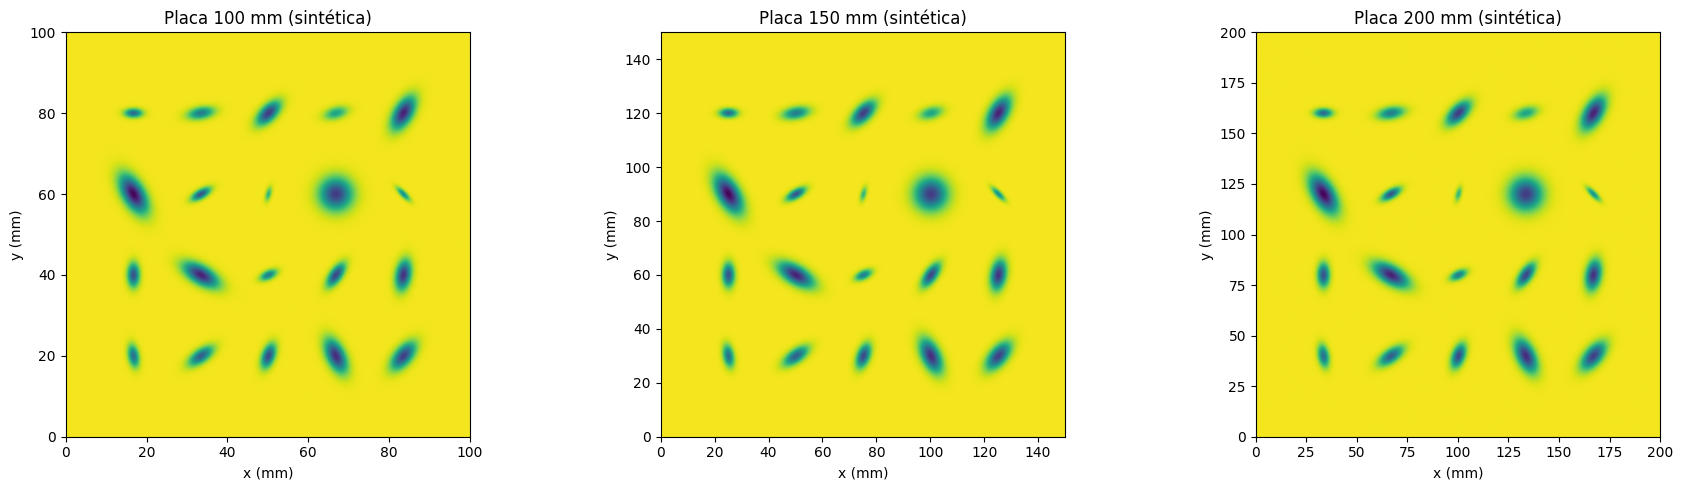

In [35]:
synth = {}
for L in PLACAS:
    Zs = build_synthetic(L, gts[L], STEP_SIM)   # paso fino propio
    N = Zs.shape[0]
    Zc = Zs - BASE
    centers_px = mm_to_px(gts[L], L, N)
    coeffs = sg2d_jacobian_projection_cv2(Zc, WINDOW_SIZE_SIM)
    est = estimate_bump_parameters(centers_px, coeffs, STEP_SIM, STEP_SIM)
    synth[L] = {'Z': Zs, 'df': build_df(gts[L], est)}

fig, axes = plt.subplots(1, len(PLACAS), figsize=(6*len(PLACAS), 5))
for ax, L in zip(np.atleast_1d(axes), PLACAS):
    ax.imshow(synth[L]['Z'], cmap='viridis', origin='lower', extent=[0, L, 0, L])
    ax.set_title(f'Placa {L} mm (sintética)')
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
plt.tight_layout()
plt.show()

In [36]:
resumen_synth = resumen_metricas({L: synth[L]['df'] for L in PLACAS}, 'SINTÉTICO')

--- SINTÉTICO ---


,rho_A,rho_s1,rho_s2,MAE_A,MAE_s1,MAE_s2
Placa (mm),,,,,,
100,0.998860,0.994463,0.999096,0.025499,0.150705,0.095251
150,0.999903,0.998485,0.999761,0.006264,0.102762,0.065691
200,0.999987,0.999063,0.999897,0.002297,0.078695,0.053037


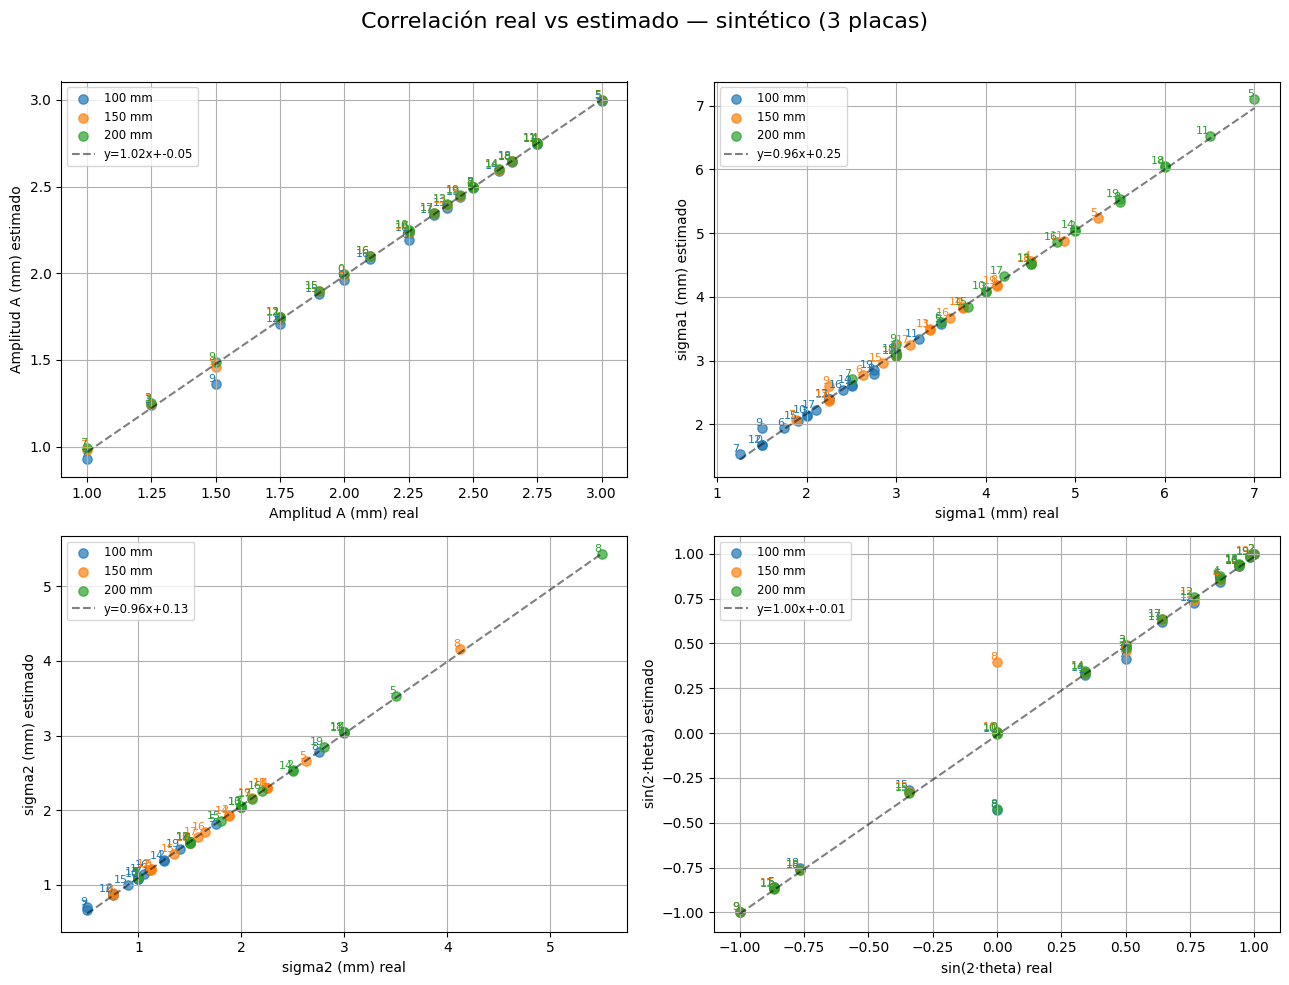

In [37]:
corr_plots_multi({L: synth[L]['df'] for L in PLACAS}, 'sintético')

## 5. Validación con el escaneo real

Se procesa el mapa completo (las 3 placas en fila) 3 veces, una por placa, con los centros proporcionados en `escaneos/centros_<L>mm.csv`.

Formato de los centros: `idx, x_px, y_px` (columna, fila en el mapa completo, sin reescalar).

El paso Y (avance) se toma de `STEP_Y`; el estimador maneja la anisotropía con los dos pasos.


Escaneo completo: (12500, 3072)
Paso X: 0.157 mm/px, Paso Y: 0.0441 mm/perfil
Tendencia por perfil eliminada (RANSAC, umbral 0.15 mm, cols 1313-2525)


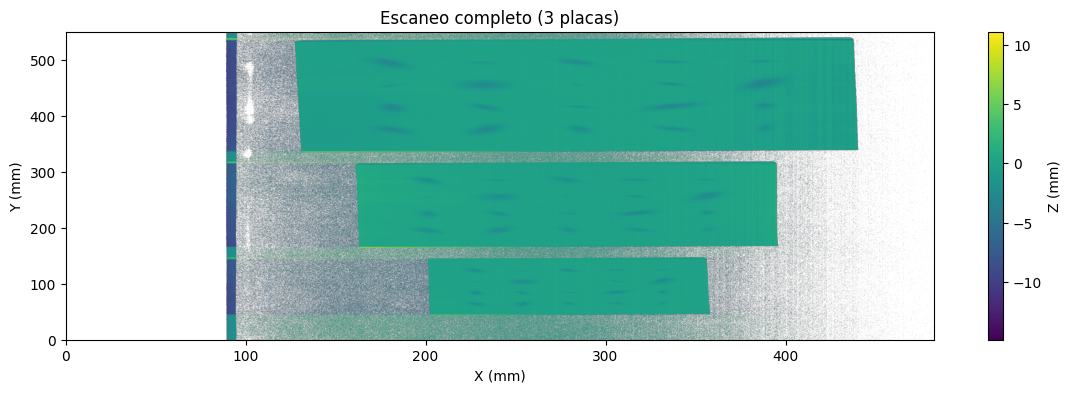

In [38]:
def cargar_escaneo(path):
    ext = path.suffix.lower()
    if ext == '.npy':
        return np.load(path)
    if ext == '.csv':
        return pd.read_csv(path).values.astype(float)
    if ext == '.npz':
        with np.load(path) as z:
            return z[z.files[0]]
    if ext in ('.tif', '.tiff'):
        from PIL import Image
        return np.array(Image.open(path), dtype=float)
    raise ValueError(f'Extensión no soportada: {ext}')


def ransac_line(x, y, n_iter=60, thresh=0.15, min_inliers=20, seed=42):
    """Ajuste de recta robusto (RANSAC) ignorando outliers (p. ej. defectos).

    x, y: puntos 1D. Devuelve (m, b) de la recta y = m·x + b,
    reajustada por mínimos cuadrados sobre los inliers.
    """
    rng = np.random.default_rng(seed)
    n = len(x)
    best_m, best_b, best_n = 0.0, 0.0, -1
    for _ in range(n_iter):
        i1, i2 = rng.choice(n, 2, replace=False)
        if abs(x[i1] - x[i2]) < 1e-9:
            continue
        m = (y[i1] - y[i2]) / (x[i1] - x[i2])
        b = y[i1] - m * x[i1]
        resid = np.abs(y - (m * x + b))
        nin = int((resid < thresh).sum())
        if nin > best_n:
            best_n, best_m, best_b = nin, m, b
    inliers = np.abs(y - (best_m * x + best_b)) < thresh
    if inliers.sum() < min_inliers:
        return best_m, best_b   # si no hay suficientes inliers, devolver lo mejor
    m, b = np.polyfit(x[inliers], y[inliers], 1)
    return m, b


Z_full = cargar_escaneo(RUTA_ESCANEO)
Z_full = Z_full.astype(np.float64)
print(f'Escaneo completo: {Z_full.shape}')
print(f'Paso X: {STEP_X} mm/px, Paso Y: {STEP_Y} mm/perfil')

# ---- Preprocesamiento: eliminar la tendencia (plano) de cada perfil ----
# Para cada fila (perfil) se ajusta una recta con los puntos entre las
# columnas C_INI y C_FIN usando RANSAC: las depresiones de los defectos
# actúan como outliers y no sesgan la recta de fondo.
C_INI, C_FIN = 1313, 2525
RANSAC_THRESH = 0.15   # mm: desviación aceptada respecto a la recta
cols_aj = np.arange(C_INI, C_FIN)
col_grid = np.arange(Z_full.shape[1])
Z_proc = Z_full.copy()
for i in range(Z_full.shape[0]):
    seg = Z_full[i, C_INI:C_FIN]
    val = np.isfinite(seg)
    if val.sum() >= 20:
        m, b = ransac_line(cols_aj[val], seg[val], thresh=RANSAC_THRESH)
        Z_proc[i] = Z_full[i] - (m * col_grid + b)
    else:
        Z_proc[i] = np.nan
Z_full = Z_proc
print(f'Tendencia por perfil eliminada (RANSAC, umbral {RANSAC_THRESH} mm, cols {C_INI}-{C_FIN})')

# Visualización del escaneo completo
plt.figure(figsize=(14, 4))
plt.imshow(Z_full, aspect='auto', cmap='viridis',
           extent=[0, Z_full.shape[1]*STEP_X, 0, Z_full.shape[0]*STEP_Y])
plt.xlabel('X (mm)'); plt.ylabel('Y (mm)')
plt.colorbar(label='Z (mm)')
plt.title('Escaneo completo (3 placas)')
plt.show()

In [39]:
# Sustracción de base: mediana del mapa (robusta a defectos y texto)
Zc_full = Z_full - np.nanmedian(Z_full)

reales = {}
for L in PLACAS:
    pc = RUTA_CENTROS(L)
    if pc.exists():
        ctr = pd.read_csv(pc)
        # Filtrar filas con centro rellenado (x_px, y_px no vacíos)
        ctr_ok = ctr.dropna(subset=['x_px', 'y_px']).copy()
        ctr_ok = ctr_ok[ctr_ok['x_px'] != '']
        ctr_ok['x_px'] = pd.to_numeric(ctr_ok['x_px'])
        ctr_ok['y_px'] = pd.to_numeric(ctr_ok['y_px'])
        print(f'Placa {L}: {len(ctr_ok)}/{len(ctr)} centros con coordenadas')
        if len(ctr_ok) == 0:
            print(f'  (sin centros, se omite esta placa)')
            continue
        # Coordenadas del CSV directamente como (fila, columna) del array.
        centers_real = [(int(r.y_px), int(r.x_px)) for _, r in ctr_ok.iterrows()]
        idxs = list(ctr_ok['idx'])
        coeffs = sg2d_jacobian_projection_cv2(Zc_full, WINDOW_SIZE)
        est = estimate_bump_parameters(centers_real, coeffs, STEP_X, STEP_Y)
        # Alinear con ground truth solo de los idx presentes
        gt_ok = gts[L][gts[L]['idx'].isin(idxs)]
        df_ok = build_df(gt_ok, est)
        reales[L] = {'df': df_ok}
        print(f'  defectos evaluados: {sorted(idxs)}')
    else:
        print(f'Placa {L}: AVISO, falta {pc.name}')

Placa 100: 0/20 centros con coordenadas
  (sin centros, se omite esta placa)
Placa 150: 0/20 centros con coordenadas
  (sin centros, se omite esta placa)
Placa 200: 5/20 centros con coordenadas
  defectos evaluados: [0, 1, 2, 3, 4]


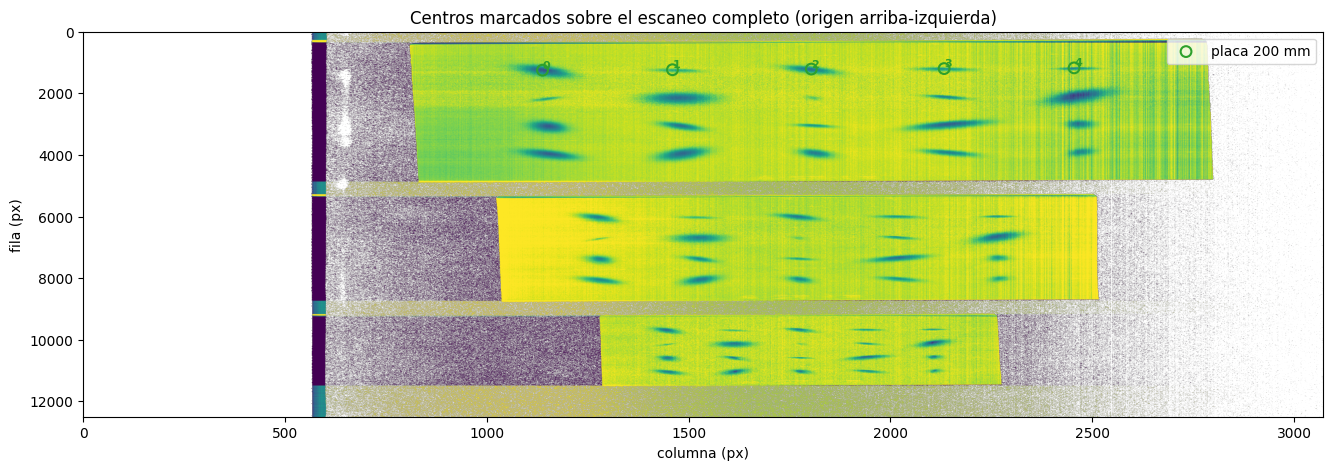

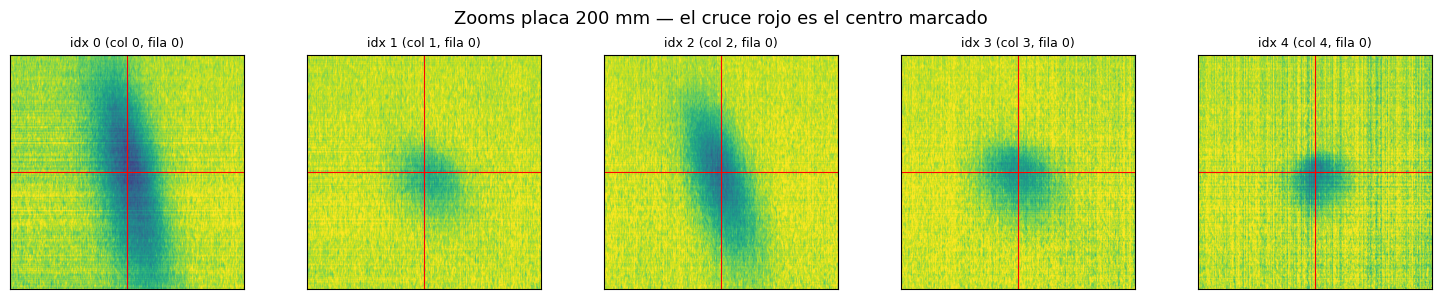

In [40]:
# ---- VERIFICACIÓN VISUAL: centros sobre el escaneo ----
# Convención de imagen: el origen (0,0) está arriba a la izquierda.
# La fila 0 del array es la fila superior de la imagen, y las coordenadas
# x_px (columna) e y_px (fila) del CSV se usan directamente.

colores = {100: 'tab:blue', 150: 'tab:orange', 200: 'tab:green'}
H_img = Zc_full.shape[0]
W_img = Zc_full.shape[1]

plt.figure(figsize=(16, 5))
plt.imshow(Zc_full, aspect='auto', cmap='viridis',
           extent=[0, W_img, H_img, 0],   # Y invertido: fila 0 arriba
           vmin=-4, vmax=0.5)
for L in PLACAS:
    pc = RUTA_CENTROS(L)
    if not pc.exists():
        continue
    ctrL = pd.read_csv(pc).dropna(subset=['x_px', 'y_px'])
    if len(ctrL) == 0:
        continue
    plt.scatter(ctrL['x_px'], ctrL['y_px'],
                s=60, marker='o', facecolors='none', edgecolors=colores[L],
                linewidths=1.5, label=f'placa {L} mm')
    for _, r in ctrL.iterrows():
        plt.text(r['x_px'], r['y_px'], str(int(r['idx'])),
                 fontsize=8, color=colores[L], fontweight='bold',
                 ha='left', va='bottom')
plt.xlabel('columna (px)'); plt.ylabel('fila (px)')
plt.title('Centros marcados sobre el escaneo completo (origen arriba-izquierda)')
plt.legend()
plt.show()

# Zoom por defecto: cada centro con su ventana local
for L in PLACAS:
    pc = RUTA_CENTROS(L)
    if not pc.exists():
        continue
    ctrL = pd.read_csv(pc).dropna(subset=['x_px', 'y_px'])
    if len(ctrL) == 0:
        continue
    n = len(ctrL)
    ncols = 5
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, r) in zip(axes, ctrL.iterrows()):
        y, x = int(r['y_px']), int(r['x_px'])
        hw = 200
        reg = Zc_full[max(0,y-hw):y+hw, max(0,x-hw):x+hw]
        ax.imshow(reg, cmap='viridis', vmin=-4, vmax=0.5,
                  extent=[x-hw, x+hw, y+hw, y-hw])  # Y invertido
        ax.set_title(f"idx {int(r['idx'])} (col {int(r['col'])}, fila {int(r['row'])})", fontsize=9)
        ax.axvline(x, color='r', lw=0.8)
        ax.axhline(y, color='r', lw=0.8)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[len(ctrL):]:
        ax.axis('off')
    plt.suptitle(f'Zooms placa {L} mm — el cruce rojo es el centro marcado', fontsize=13)
    plt.tight_layout()
    plt.show()

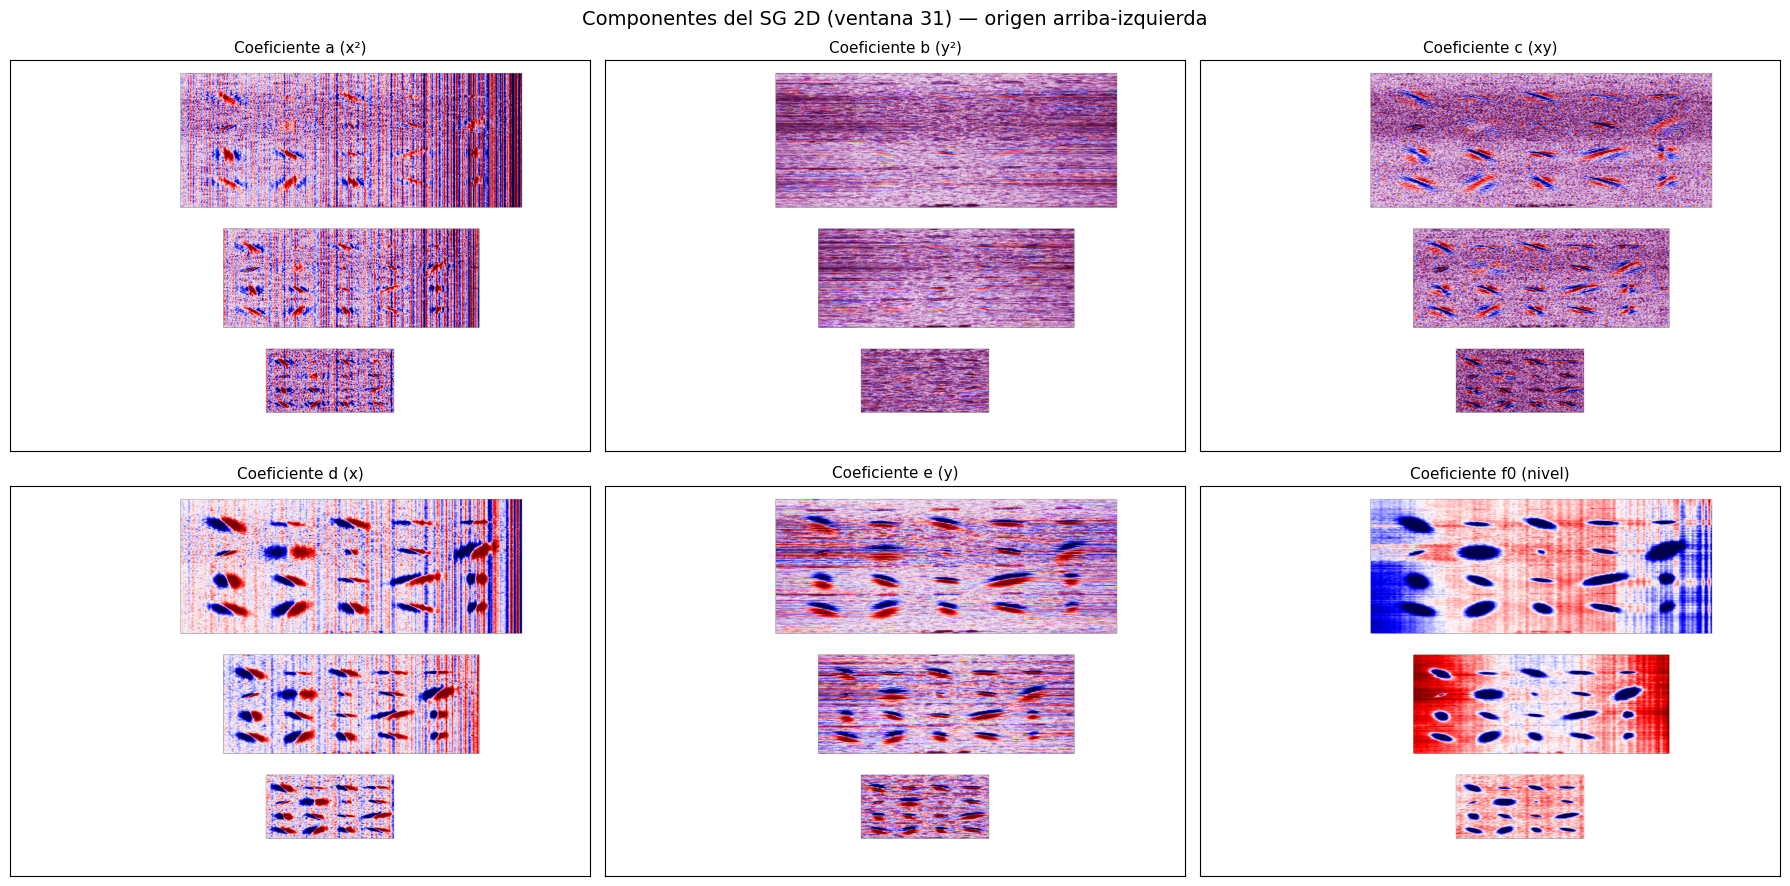

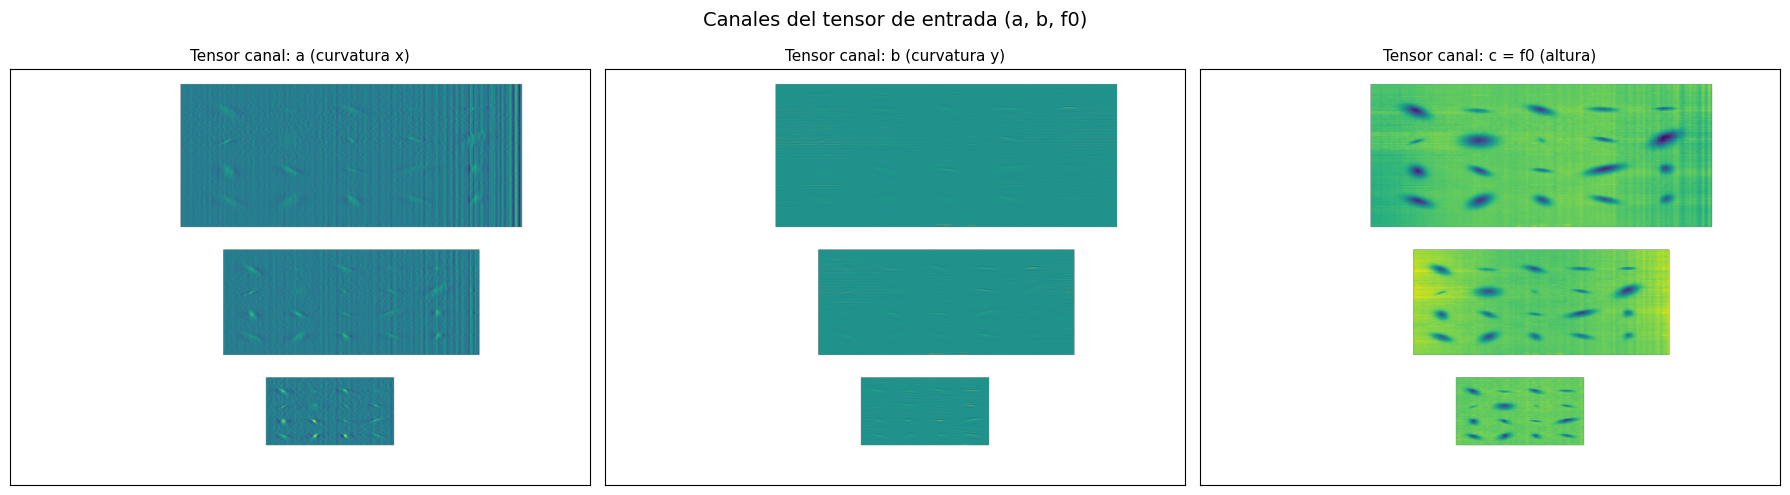

In [41]:
# ---- Componentes del Savitzky-Golay 2D (coeficientes del polinomio local) ----
# Se muestra cada coeficiente del ajuste cuadrático local sobre el escaneo.
# f(x,y) = a·x² + b·y² + c·x·y + d·x + e·y + f0

coeffs_viz = sg2d_jacobian_projection_cv2(Zc_full, WINDOW_SIZE)
nombres = ['a (x²)', 'b (y²)', 'c (xy)', 'd (x)', 'e (y)', 'f0 (nivel)']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (k, nom) in zip(axes.ravel(), enumerate(nombres)):
    mapa = coeffs_viz[:, :, k]
    vmax = np.nanpercentile(np.abs(mapa[~np.isnan(mapa)]), 95)
    ax.imshow(mapa, aspect='auto', cmap='seismic',
              extent=[0, W_img, H_img, 0],
              vmin=-vmax, vmax=vmax)
    ax.set_title(f'Coeficiente {nom}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f'Componentes del SG 2D (ventana {WINDOW_SIZE}) — origen arriba-izquierda', fontsize=14)
plt.tight_layout()
plt.show()

# Los 3 canales del tensor de entrada de la red: a, b y f0 (normalizados)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (k, nom) in zip(axes, [(0, 'a (curvatura x)'), (1, 'b (curvatura y)'), (5, 'c = f0 (altura)')]):
    mapa = coeffs_viz[:, :, k]
    ax.imshow(mapa, aspect='auto', cmap='viridis',
              extent=[0, W_img, H_img, 0])
    ax.set_title(f'Tensor canal: {nom}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Canales del tensor de entrada (a, b, f0)', fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
if reales:
    resumen_real = resumen_metricas({L: reales[L]['df'] for L in reales}, 'REAL')

--- REAL ---


,rho_A,rho_s1,rho_s2,MAE_A,MAE_s1,MAE_s2
Placa (mm),,,,,,
200,0.491172,-0.338235,-0.140768,0.480091,2.935078,0.734299


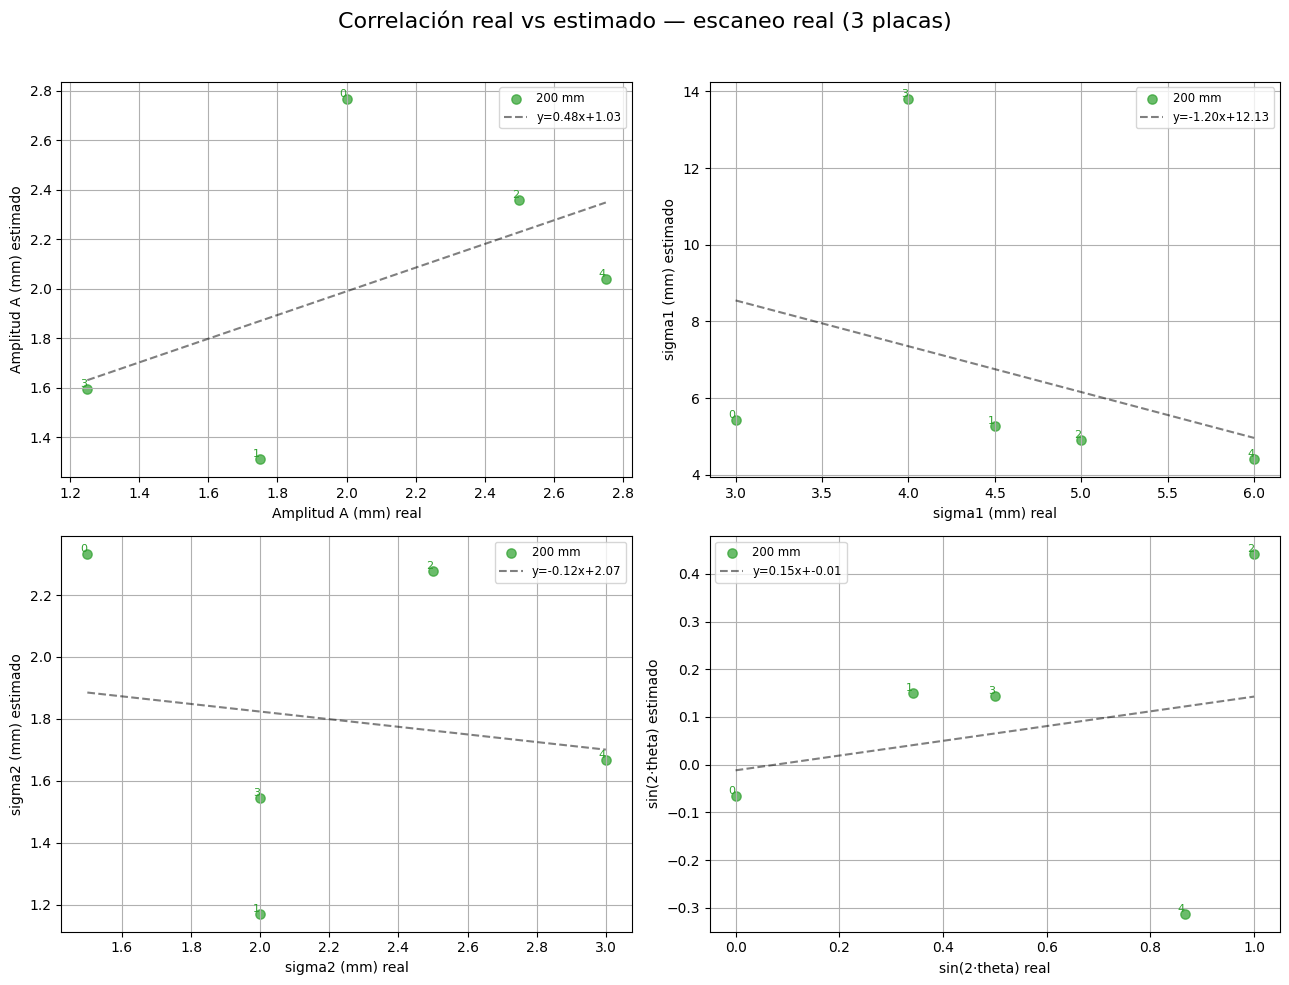

In [43]:
if reales:
    corr_plots_multi({L: reales[L]['df'] for L in reales}, 'escaneo real')

## 6. Comparativa sintético vs real

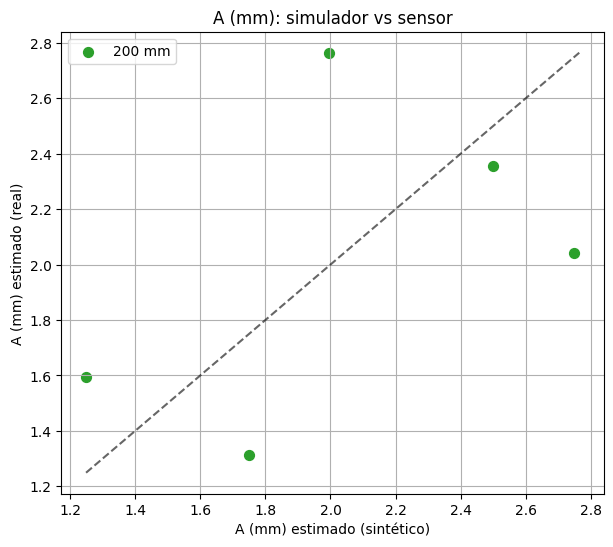

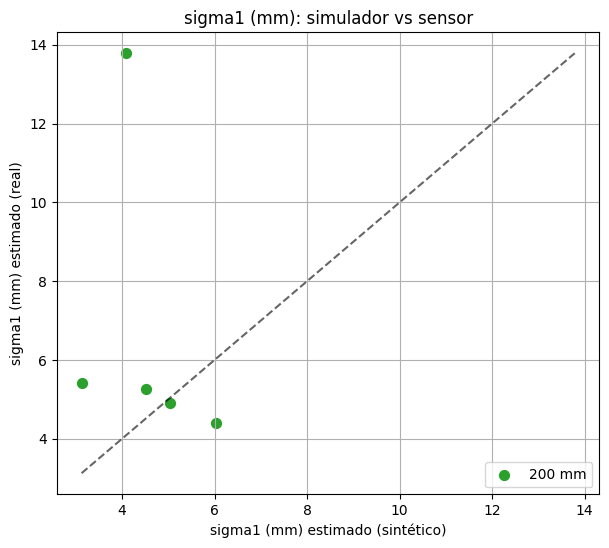

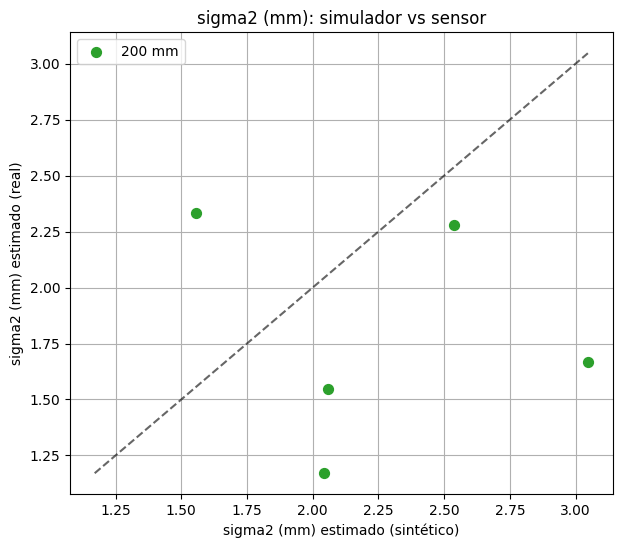

In [44]:
if reales:
    params = [('A', 'A (mm)'), ('s1', 'sigma1 (mm)'), ('s2', 'sigma2 (mm)')]
    colores = {100: 'tab:blue', 150: 'tab:orange', 200: 'tab:green'}
    for col, lab in params:
        plt.figure(figsize=(7, 6))
        todos_x, todos_y = [], []
        for L in PLACAS:
            if L not in reales or len(reales[L]['df']) == 0:
                continue
            s, r = synth[L]['df'], reales[L]['df']
            m = s.merge(r[['idx', f'{col}_est']], on='idx', suffixes=('_s', '_r'))
            xv = m[f'{col}_est_s']; yv = m[f'{col}_est_r']
            todos_x += list(xv); todos_y += list(yv)
            plt.scatter(xv, yv, s=50, color=colores[L], label=f'{L} mm')
        if todos_x:
            lims = [min(todos_x + todos_y), max(todos_x + todos_y)]
            plt.plot(lims, lims, 'k--', alpha=0.6)
        plt.xlabel(f'{lab} estimado (sintético)')
        plt.ylabel(f'{lab} estimado (real)')
        plt.title(f'{lab}: simulador vs sensor')
        plt.grid(True)
        plt.legend()
        plt.show()

## 7. Tabla comparativa final

In [45]:
if reales:
    filas = []
    for L in PLACAS:
        if L not in reales or len(reales[L]['df']) == 0:
            continue
        s, r = synth[L]['df'], reales[L]['df']
        for col, lab in [('A', 'A (mm)'), ('s1', 'sigma1 (mm)'), ('s2', 'sigma2 (mm)')]:
            m = s.merge(r[['idx', f'{col}_est']], on='idx', suffixes=('_s', '_r'))
            if len(m) > 2 and m[f'{col}_est_s'].nunique() > 1:
                rho_s = np.corrcoef(m[f'{col}_real'], m[f'{col}_est_s'])[0, 1]
            else:
                rho_s = np.nan
            if len(m) > 2 and m[f'{col}_est_r'].nunique() > 1:
                rho_r = np.corrcoef(m[f'{col}_real'], m[f'{col}_est_r'])[0, 1]
            else:
                rho_r = np.nan
            filas.append({'Placa': f'{L} mm', 'Parámetro': lab,
                          'n': len(m),
                          'rho_sintético': rho_s,
                          'rho_real': rho_r,
                          'MAE_sintético (mm)': np.mean(abs(m[f'{col}_real']-m[f'{col}_est_s'])),
                          'MAE_real (mm)': np.mean(abs(m[f'{col}_real']-m[f'{col}_est_r']))})
    display(pd.DataFrame(filas))

,Placa,Parámetro,n,rho_sintético,rho_real,MAE_sintético (mm),MAE_real (mm)
0,200 mm,A (mm),5,0.999997,0.491172,0.001366,0.480091
1,200 mm,sigma1 (mm),5,0.999735,-0.338235,0.058811,2.935078
2,200 mm,sigma2 (mm),5,0.999933,-0.140768,0.048267,0.734299
